In [2]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit.quantum_info import random_unitary

/home/lukas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
def fourier_gate(d):
    """
    Generates a Fourier Transform gate for a d-dimensional system.
    F|j> = 1/sqrt(d) * sum_k (omega^(jk) |k>)
    """
    omega = np.exp(2j * np.pi / d)
    F = np.zeros((d, d), dtype=complex)
    for j in range(d):
        for k in range(d):
            F[k, j] = (1 / np.sqrt(d)) * (omega**(j * k))
    return F

def sum_gate(d):
    """
    Generates a SUM gate for a d-dimensional system (qudits).
    Logic: |b>|a> -> |(a+b)%d>|a> 
    where 'a' is the control (LSB) and 'b' is the target (MSB).
    """
    dim = d**2
    SUM = np.zeros((dim, dim), dtype=complex)
    
    for a in range(d):
        for b in range(d):
            # Fix endianness: 'a' is LSB block, 'b' is MSB block
            inp = a + d*b
            out = a + d*((a+b) % d)
            SUM[out, inp] = 1
    return SUM

def x_gate(d):
    """
    Generates the X gate
    """
    X = np.zeros((d, d), dtype=complex)
    for j in range(d):
        # We want 1 at (row=j, col=(j+1)%d)
        X[j, (j + 1) % d] = 1
    return X

def z_gate(d):
    """
    Generates a generalized Z (phase) gate.
    Z = sum_j omega^j |j><j|
    """
    omega = np.exp(2j * np.pi / d)
    Z = np.zeros((d, d), dtype=complex)
    for j in range(d):
        Z[j, j] = omega**j
    return Z

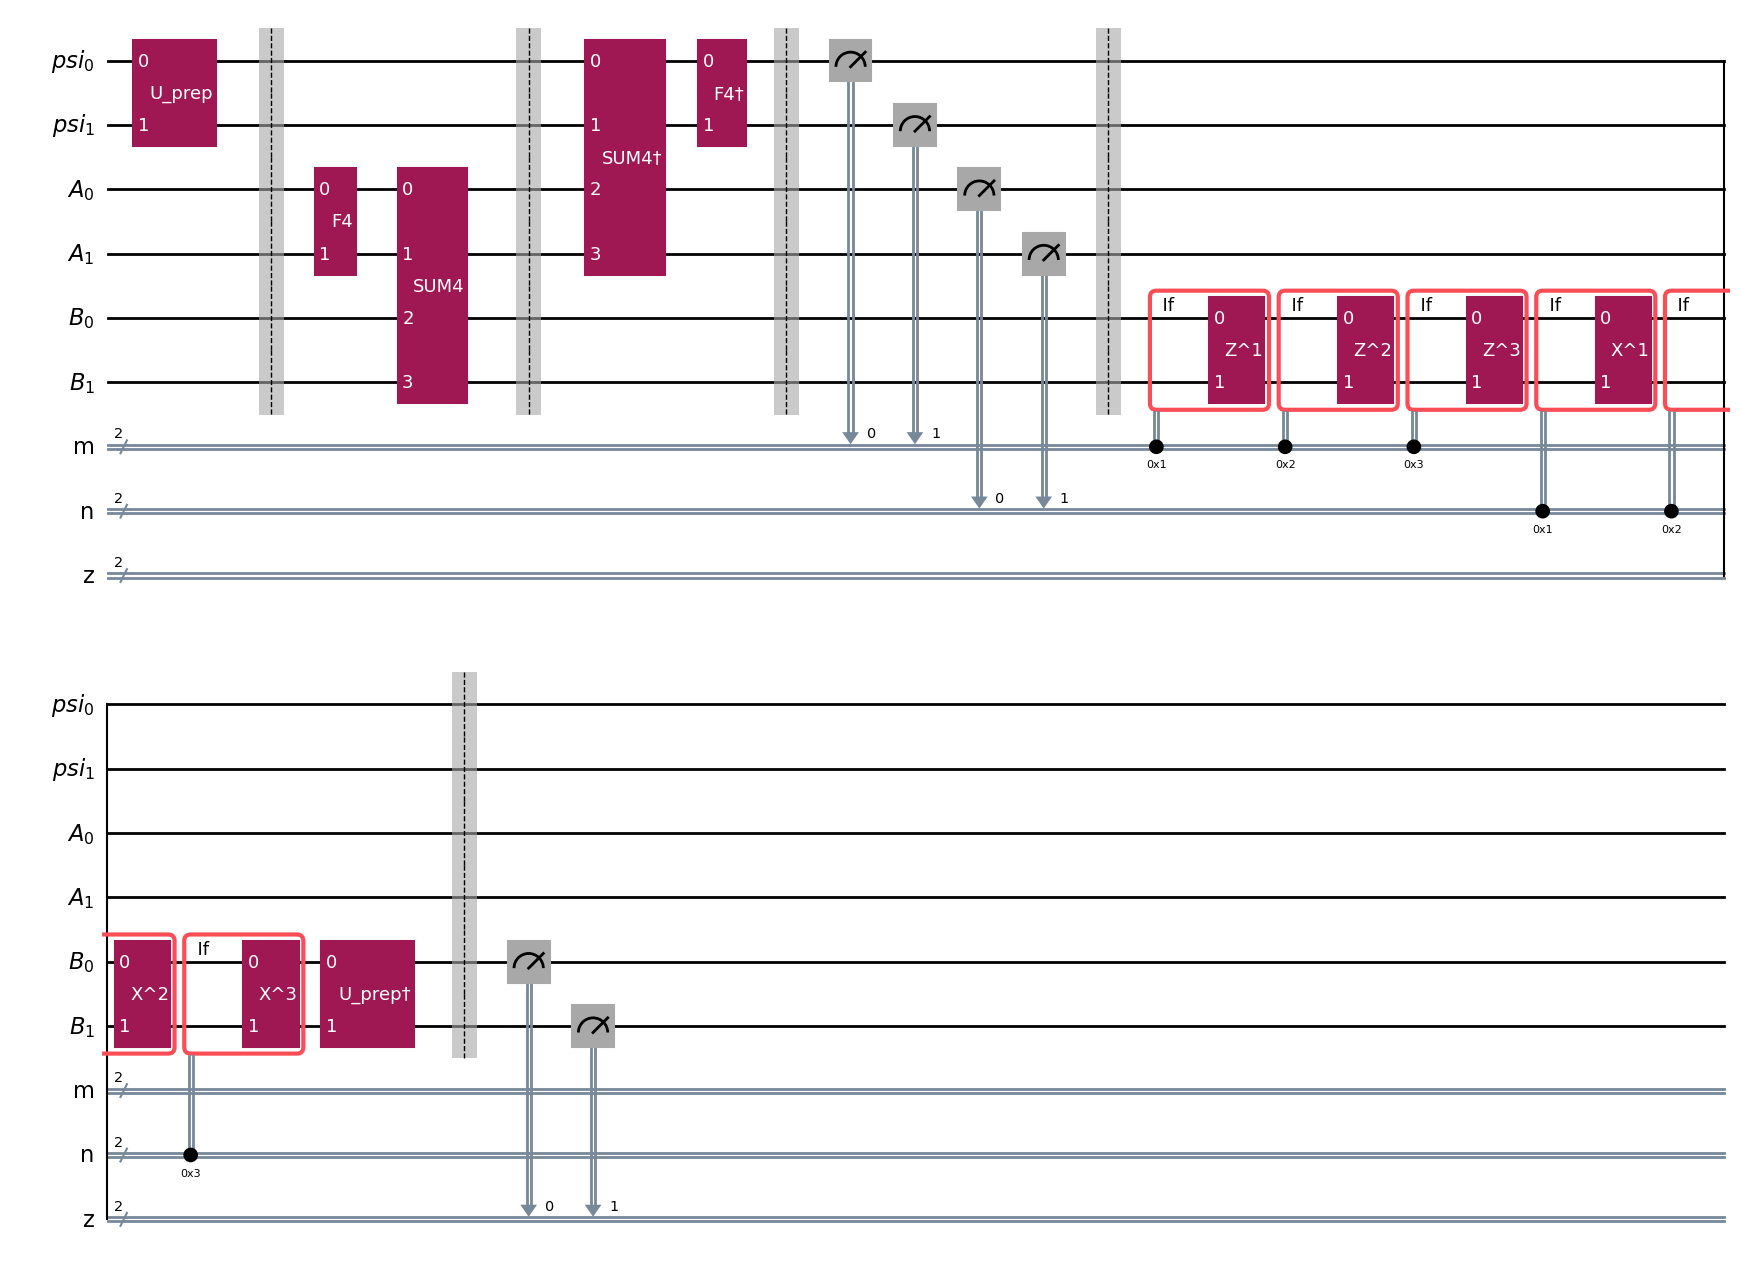

In [45]:
# -----------------------
# Initialize Gates for d=4
# -----------------------
d = 4
F = fourier_gate(d)
SUM = sum_gate(d)
X = x_gate(d)
Z = z_gate(d)
U_prep = random_unitary(d, seed=1443)  # Random state preparation

bits = int(np.log2(d))

psi = QuantumRegister(bits, "psi")
A = QuantumRegister(bits, "A")
B = QuantumRegister(bits, "B")
cr_m = ClassicalRegister(bits, "m") # Encodes m (from psi)
cr_n = ClassicalRegister(bits, "n") # Encodes n (from A)
cr_z = ClassicalRegister(bits, "z") # Encodes verification (Bob)

qc = QuantumCircuit(psi, A, B, cr_m, cr_n, cr_z)

# ==========================================
# 1. Prepare completely UNKNOWN/RANDOM state
# ==========================================

qc.unitary(U_prep, psi, label="U_prep")
qc.barrier()

qc.unitary(F, A, label=f"F{d}")
qc.unitary(SUM, [*A,*B], label=f"SUM{d}")
qc.barrier()

qc.unitary(SUM.T, [*psi,*A], label=f"SUM{d}†")
qc.unitary(np.conjugate(F.T), psi, label=f"F{d}†")
qc.barrier()

# Measure into specific registers
qc.measure(psi, cr_m)
qc.measure(A, cr_n)
qc.barrier()

X_powers = [np.linalg.matrix_power(X,i) for i in range(d)]
Z_powers = [np.linalg.matrix_power(Z,i) for i in range(d)]
# Apply Z^m correction based on m register
for m in range(1,d):
    with qc.if_test((cr_m, m)):
        qc.unitary(Z_powers[m], B, label=f"Z^{m}")
# Apply X^n correction based on n register
for n in range(1,d):
    with qc.if_test((cr_n, n)):
        qc.unitary(X_powers[n], B, label=f"X^{n}")

# ==========================================
# 6. Verify teleportation
# ==========================================
qc.unitary(U_prep.adjoint(), B, label="U_prep†")

qc.barrier()

qc.measure(B, cr_z)
qc.draw("mpl")

In [38]:
from qiskit_aer import AerSimulator

sampler = Sampler(mode=AerSimulator())

job = sampler.run([qc])
res = job.result()

In [47]:
service = QiskitRuntimeService()
backend = service.backend("ibm_torino")
pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)
sampler = Sampler(mode=backend)

job = sampler.run([qc_isa])
res = job.result()

Succes rate: 55.83%


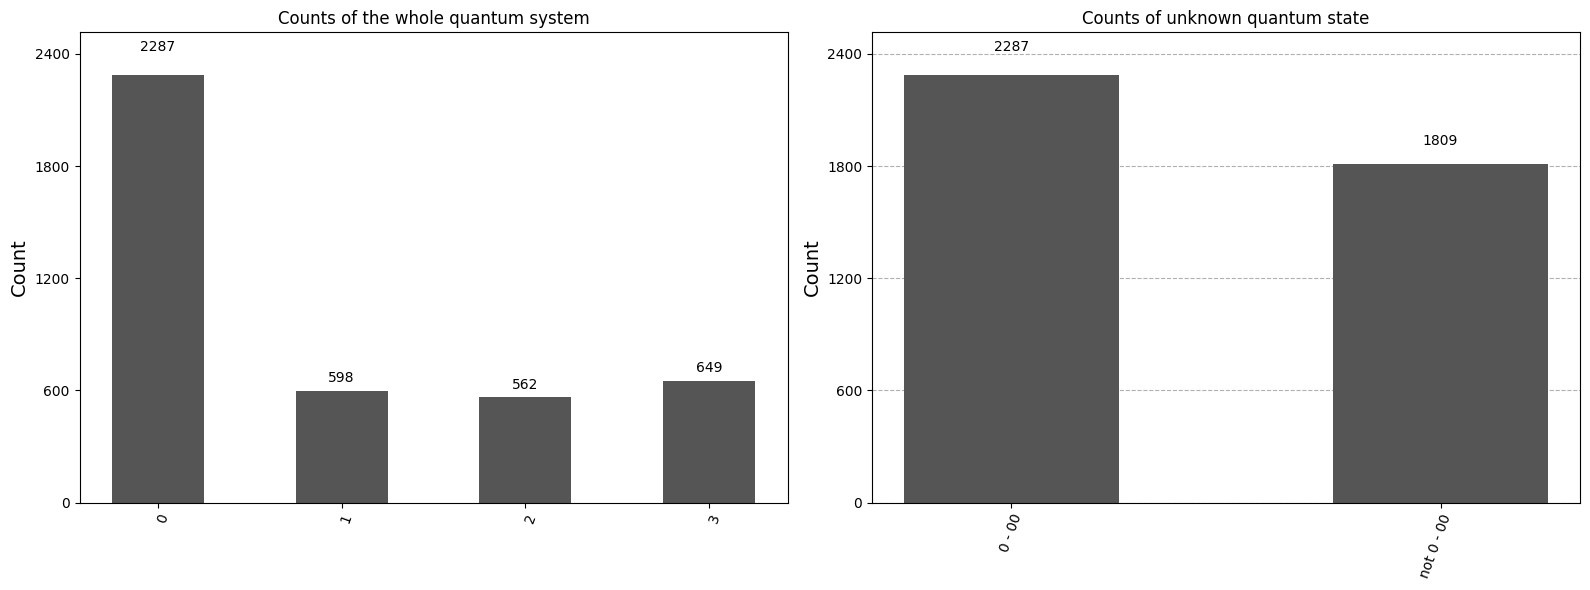

In [48]:
# Retrieve bitstrings for all registers from the result
z_bits = res[0].data.z.get_bitstrings()
n_bits = res[0].data.n.get_bitstrings()
m_bits = res[0].data.m.get_bitstrings()

# --- Data Preparation ---

# 1. Bob's Final State (0-3)
bob_data = {str(i): 0 for i in range(d)}
for z in z_bits:
    bob_data[str(int(z, 2))] += 1

# 2. Success vs Failure
# Failure is when Bob's state is not 0
success_count = bob_data.get('0', 0)
total_shots = len(z_bits)
failure_count = total_shots - success_count

sf_data = {'0 - 00': success_count, 'not 0 - 00': failure_count}

# --- Plotting Side-by-Side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Bob's Final State
plot_histogram(bob_data, ax=ax1, color='#555555')
ax1.set_title("Counts of the whole quantum system") 

# Graph 2: Success vs Failure
plot_histogram(sf_data, ax=ax2, color='#555555', title="Counts of unknown quantum state")

print("Succes rate: {:.2f}%".format(100 * success_count / total_shots))
plt.tight_layout()
plt.show()